Missing Values:
 Customer_ID        0
Age                0
Gender             0
Tenure             0
Balance            0
CreditScore        0
EstimatedSalary    0
NumOfProducts      0
IsActiveMember     0
Churn              0
dtype: int64

Statistics:
          Customer_ID            Age         Gender         Tenure  \
count  100000.000000  100000.000000  100000.000000  100000.000000   
mean    50000.500000      43.984060       0.498910       4.988760   
std     28867.657797      15.251827       0.500001       3.163744   
min         1.000000      18.000000       0.000000       0.000000   
25%     25000.750000      31.000000       0.000000       2.000000   
50%     50000.500000      44.000000       0.000000       5.000000   
75%     75000.250000      57.000000       1.000000       8.000000   
max    100000.000000      70.000000       1.000000      10.000000   

             Balance    CreditScore  EstimatedSalary  NumOfProducts  \
count  100000.000000  100000.000000    100000.000000 

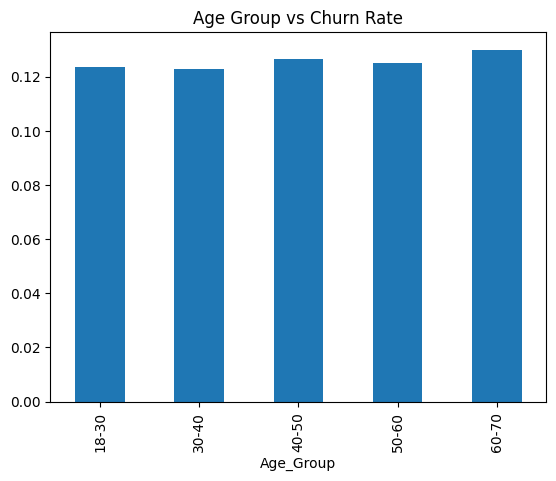

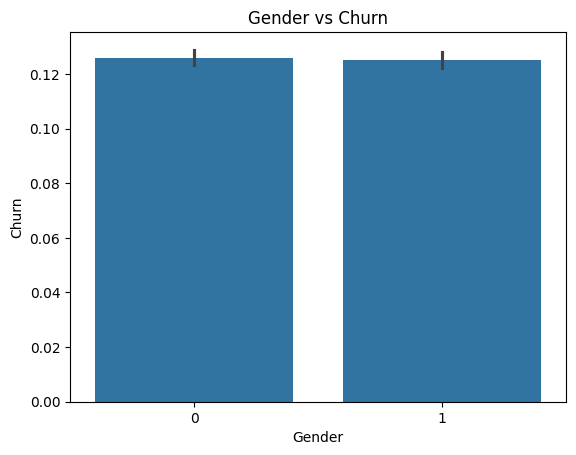

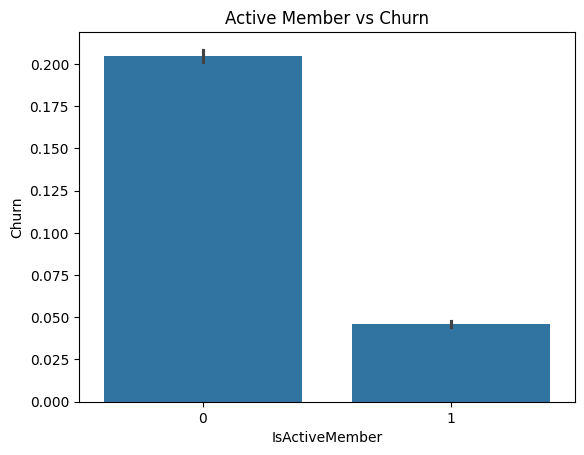

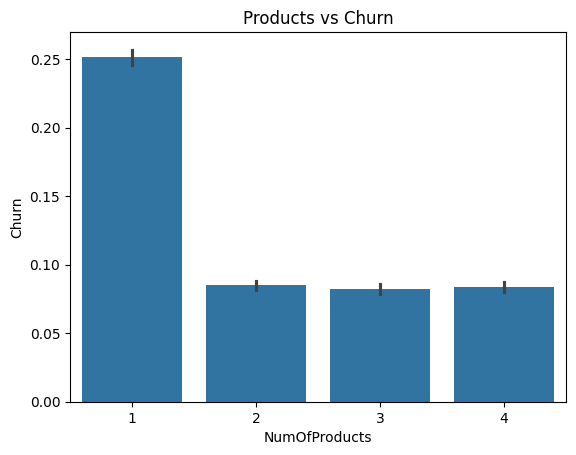

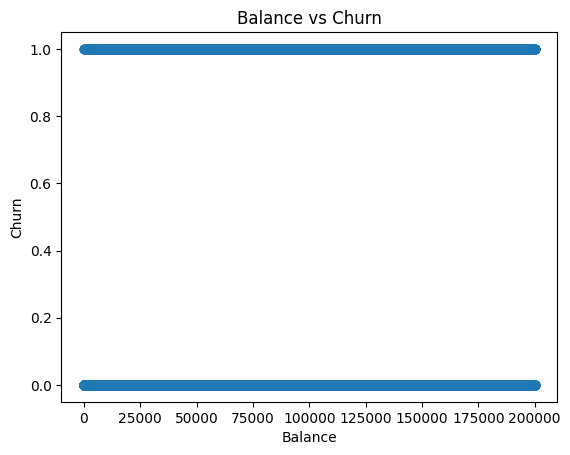

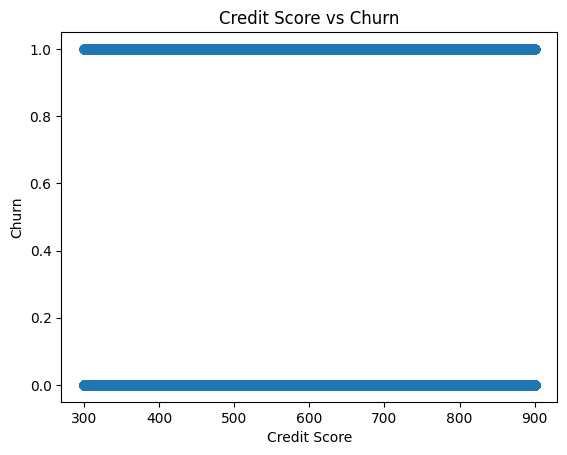

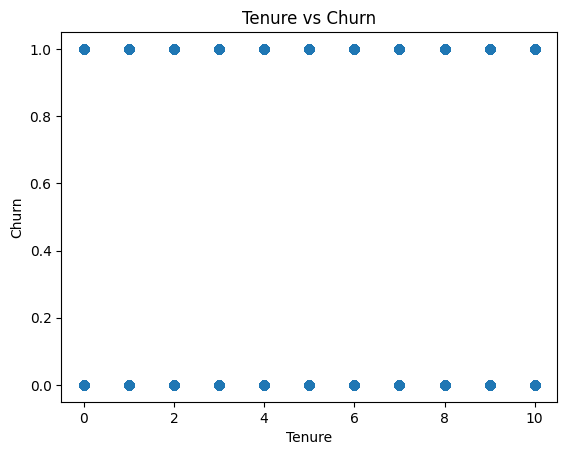

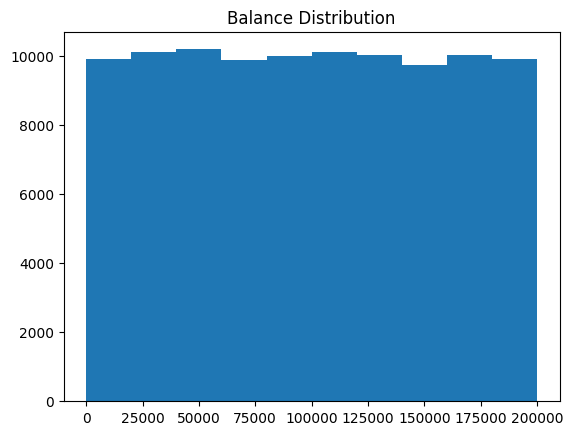

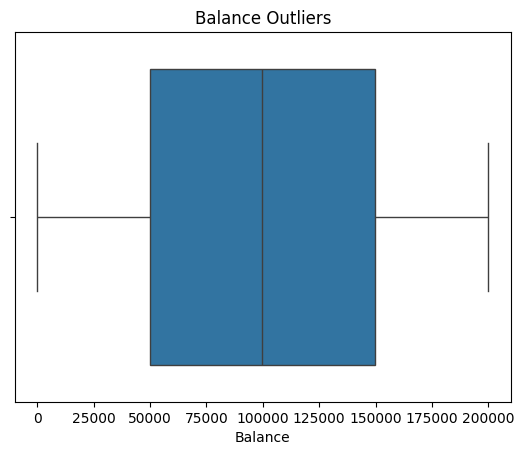

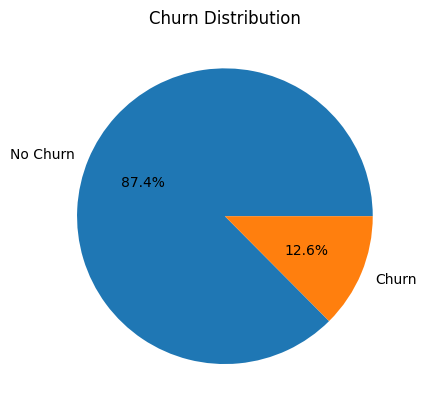


Analysis Completed Successfully ✅


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Generate Synthetic Data
np.random.seed(42)

n = 100000

data = pd.DataFrame({
    "Customer_ID": range(1, n+1),
    "Age": np.random.randint(18, 71, n),
    "Gender": np.random.choice(["Male", "Female"], n),
    "Tenure": np.random.randint(0, 11, n),
    "Balance": np.random.randint(0, 200001, n),
    "CreditScore": np.random.randint(300, 901, n),
    "EstimatedSalary": np.random.randint(10000, 150001, n),
    "NumOfProducts": np.random.randint(1, 5, n),
    "IsActiveMember": np.random.choice(["Yes", "No"], n)
})

# 2. Create Churn Column (Logic-based)
def churn_logic(row):
    if (row["IsActiveMember"] == "No" and
        row["Balance"] > 100000 and
        row["CreditScore"] < 500):
        return 1
    elif (row["Tenure"] < 2 and row["NumOfProducts"] == 1):
        return 1
    else:
        return 0

data["Churn"] = data.apply(churn_logic, axis=1)

# 3. Data Cleaning
print("Missing Values:\n", data.isnull().sum())

# Convert categorical to numeric
data["Gender"] = data["Gender"].map({"Male": 0, "Female": 1})
data["IsActiveMember"] = data["IsActiveMember"].map({"Yes": 1, "No": 0})

# 4. Descriptive Statistics
print("\nStatistics:\n", data.describe())

# 5. Churn Analysis
churn_count = data["Churn"].value_counts()
print("\nChurn Distribution:\n", churn_count)

# 6. Age Group vs Churn
data["Age_Group"] = pd.cut(data["Age"], bins=[18,30,40,50,60,70],
                          labels=["18-30","30-40","40-50","50-60","60-70"])

age_churn = data.groupby("Age_Group", observed=False)["Churn"].mean()
age_churn.plot(kind='bar')
plt.title("Age Group vs Churn Rate")
plt.show()

# 7. Gender vs Churn
sns.barplot(x="Gender", y="Churn", data=data)
plt.title("Gender vs Churn")
plt.show()

# 8. Active vs Inactive
sns.barplot(x="IsActiveMember", y="Churn", data=data)
plt.title("Active Member vs Churn")
plt.show()

# 9. Products vs Churn
sns.barplot(x="NumOfProducts", y="Churn", data=data)
plt.title("Products vs Churn")
plt.show()

# 10. Balance vs Churn
plt.scatter(data["Balance"], data["Churn"])
plt.xlabel("Balance")
plt.ylabel("Churn")
plt.title("Balance vs Churn")
plt.show()

# 11. Credit Score vs Churn
plt.scatter(data["CreditScore"], data["Churn"])
plt.xlabel("Credit Score")
plt.ylabel("Churn")
plt.title("Credit Score vs Churn")
plt.show()

# 12. Tenure vs Churn
plt.scatter(data["Tenure"], data["Churn"])
plt.xlabel("Tenure")
plt.ylabel("Churn")
plt.title("Tenure vs Churn")
plt.show()

# 13. Histogram
plt.hist(data["Balance"])
plt.title("Balance Distribution")
plt.show()

# 14. Boxplot
sns.boxplot(x=data["Balance"])
plt.title("Balance Outliers")
plt.show()

# 15. Pie Chart
plt.pie(churn_count, labels=["No Churn", "Churn"], autopct='%1.1f%%')
plt.title("Churn Distribution")
plt.show()



# Save dataset
data.to_csv("customer_churn_data.csv", index=False)

print("\nAnalysis Completed Successfully ✅")